<a href="https://colab.research.google.com/github/yizhoucc/turtorials/blob/main/notebooks/LDM_base_sort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LDM base sort demo

goal, a very basic sorting to display more relavent items to a user on home screen.

infomation we can use: relative distance, relative time released. released by a verified user or not.

## plan:
split the verify/no verify into 2 categroies. say home screen we show 10 items. we use a p to adjust how many verified item we show. say 80% verified and 20% no.

for each categroy, we score the item based on relative time and space distance. given the space is a


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm


In [57]:
def get_cosine_similarity(u, v):
    return np.dot(u, v) / (norm(u) * norm(v))


relative dist:1 miles    relative_time:0.0 day
relative dist:5 miles    relative_time:1.6 day
relative dist:9 miles    relative_time:0.9 day
relative dist:7 miles    relative_time:3.9 day
relative dist:2 miles    relative_time:7.2 day
relative dist:6 miles    relative_time:7.2 day
relative dist:6 miles    relative_time:8.8 day
relative dist:8 miles    relative_time:9.7 day
relative dist:16 miles    relative_time:6.5 day
relative dist:25 miles    relative_time:9.7 day


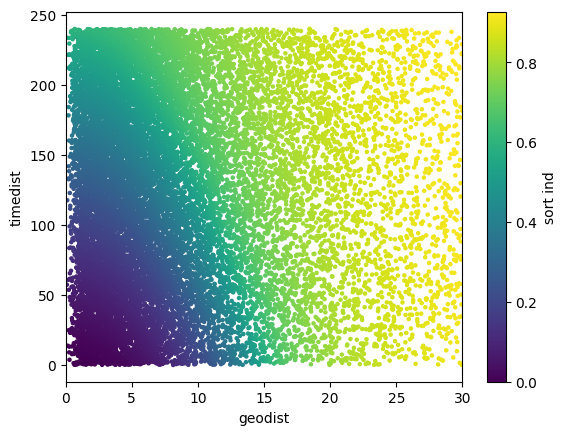

In [192]:
numitem=20000
p=0.8 # 80% verified, 20% not verified, to show.
geodist = np.random.lognormal(2, 1, size=(numitem,)) # 2d uniform scatter converted to 1d distance should be a R distrubtion, use log normal for demo simplisity here.
timedist= np.random.uniform(low=0.1, high=24*10, size=(numitem,))

def score(space, time, alpha=0.5):
    # adjust alpha to move the weights.
    # space is 2nd order
    return space**2*alpha + time*(1-alpha)
sortinds=np.argsort( score(geodist, timedist))
for i in sortinds[:numitem:numitem//10]:
  print(f'relative dist:{geodist[i]:.0f} miles  \
  relative_time:{timedist[i]/24:.1f} day')


mask=geodist[sortinds]<30
plt.scatter(geodist[sortinds][mask], timedist[sortinds][mask], c=np.linspace(0,1,numitem)[mask], s=5)
plt.xlabel('geodist')
plt.ylabel('timedist')
plt.xlim(0,30)
plt.colorbar(label='sort ind')
plt.show()